# **Programação Linear - Aula 1 a 6**

In [ ]:
#Instalar biblioteca Pulp
!pip install pulp

In [ ]:
#Importar biblioteca
from pulp import *

In [ ]:
# Criar variável modelo contendo dados do problema
problema_1 = pulp.LpProblem('linear_programming', LpMaximize)

# Definir variáveis de decisão
perfume_1 = LpVariable('x1', lowBound = 0)
perfume_2 = LpVariable('x2', lowBound = 0)

# Definir função objetivo
problema_1 += 3*perfume_1 + 5*perfume_2

# Definir restrições
problema_1 += 2*perfume_1 + 1*perfume_2 <= 230
problema_1 += 1*perfume_1 + 2*perfume_2 <= 250
problema_1 += 0*perfume_1 + 1*perfume_2 <= 120

# Resolver
results = problema_1.solve()

# Apresentar resultados
status = {"Optimal":"Solução ótima",
          "Not Solved":"Não resolvido",
          "Infeasible":"Infactível",
          "Unbounded":"Ilimitado",
          "Undefined":"Indefinido"}
print(status[LpStatus[results]])
print(f'Solução: z* = {value(problema_1.objective)}')
print(f'Parâmetros: x* = {value(perfume_1)}, y* = {value(perfume_2)}')



Solução ótima
Solução: z* = 660.0
Parâmetros: x* = 70.0, y* = 90.0


In [ ]:
# Criar variável modelo contendo dados do problema
problema_1 = pulp.LpProblem('linear_programming', LpMaximize)

# Definir variáveis de decisão
carrinho = LpVariable('x1', lowBound = 0)
triciclo = LpVariable('x2', lowBound = 0)

# Definir função objetivo
problema_1 += 12*carrinho + 60*triciclo

# Definir restrições
problema_1 += 0.25*carrinho + 0.5*triciclo <= 36
problema_1 += 0.1*carrinho + 0.75*triciclo <= 22
problema_1 += 0.1*carrinho + 0.4*triciclo <= 15

# Resolver
results = problema_1.solve()

# Apresentar resultados
status = {"Optimal":"Solução ótima",
          "Not Solved":"Não resolvido",
          "Infeasible":"Infactível",
          "Unbounded":"Ilimitado",
          "Undefined":"Indefinido"}
print(status[LpStatus[results]])
print(f'Solução: z* = {value(problema_1.objective)}')
print(f'Parâmetros: x* = {value(carrinho)}, y* = {value(triciclo)}')



Solução ótima
Solução: z* = 2040.0
Parâmetros: x* = 70.0, y* = 20.0


# **Aplicações de Regressão Linear na Engenharia de Computação - Aula 7**

### Aplicação: Previsão da Latência em Redes (Otimizado com IA)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Dados fictícios
bandwidth = np.random.uniform(10, 100, 100)  # Mbps
num_devices = np.random.randint(1, 20, 100)  # Dispositivos conectados
latency = 50 - (bandwidth * 0.2) + (num_devices * 2) + np.random.normal(0, 3, 100)

df2 = pd.DataFrame({'Bandwidth (Mbps)': bandwidth, 'Num Devices': num_devices, 'Latency (ms)': latency})

# Criando variáveis de entrada e saída
X = df2[['Bandwidth (Mbps)', 'Num Devices']]
y = df2['Latency (ms)']

# Dividindo dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configurando Pipeline com escalonamento e modelo com regularização
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Padronização
    ('regressor', Ridge(alpha=1.0))  # Regressão com regularização Ridge
])

# Treinando o modelo
pipeline.fit(X_train, y_train)

# Fazendo previsões
y_pred = pipeline.predict(X_test)

# Imprimindo coeficientes regularizados
regressor = pipeline.named_steps['regressor']
for i, col_name in enumerate(X_train.columns):
    print(f"Coeficiente regularizado de '{col_name}': {regressor.coef_[i]:.2f}")


Coeficiente regularizado de 'Bandwidth (Mbps)': -5.34
Coeficiente regularizado de 'Num Devices': 10.59


### Aplicação: Previsão da Latência em Redes (Otimizado e compactado com IA)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Dados fictícios e criação do dataframe
df2 = pd.DataFrame({
    'Bandwidth (Mbps)': np.random.uniform(10, 100, 100),
    'Num Devices': np.random.randint(1, 20, 100),
    'Latency (ms)': 50 - (np.random.uniform(10, 100, 100) * 0.2)
                    + (np.random.randint(1, 20, 100) * 2)
                    + np.random.normal(0, 3, 100)
})

# Divisão de dados e criação do Pipeline
X_train, X_test, y_train, y_test = train_test_split(df2[['Bandwidth (Mbps)', 'Num Devices']], df2['Latency (ms)'], test_size=0.2, random_state=42)
pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge(alpha=1.0))])
pipeline.fit(X_train, y_train)

# Impressão dos coeficientes regularizados
for i, col_name in enumerate(X_train.columns):
    print(f"Coeficiente regularizado de '{col_name}': {pipeline.named_steps['regressor'].coef_[i]:.2f}")


Coeficiente regularizado de 'Bandwidth (Mbps)': 0.26
Coeficiente regularizado de 'Num Devices': 0.36


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Dados fictícios
bandwidth = np.random.uniform(10, 100, 100)  # Mbps
num_devices = np.random.randint(1, 20, 100)  # Dispositivos conectados
latency = 50 - (bandwidth * 0.2) + (num_devices * 2) + np.random.normal(0, 3, 100)

df2 = pd.DataFrame({'Bandwidth (Mbps)': bandwidth, 'Num Devices': num_devices, 'Latency (ms)': latency})

# Criando o modelo com engenharia de recursos
df2['Bandwidth_squared'] = df2['Bandwidth (Mbps)'] ** 2  # Captura de relações não lineares
X = df2[['Bandwidth (Mbps)', 'Num Devices', 'Bandwidth_squared']]
y = df2['Latency (ms)']

# Divisão dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configuração do pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Padronização
    ('regressor', Ridge(alpha=1.0))  # Regressão com regularização Ridge
])

# Treinamento do modelo
pipeline.fit(X_train, y_train)

# Previsões e cálculo do erro
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro quadrático médio (MSE): {mse:.2f}")

# Exibição dos coeficientes
regressor = pipeline.named_steps['regressor']
for i, col_name in enumerate(X_train.columns):
    print(f"Coeficiente regularizado de '{col_name}': {regressor.coef_[i]:.2f}")


Erro quadrático médio (MSE): 5.69
Coeficiente regularizado de 'Bandwidth (Mbps)': -3.21
Coeficiente regularizado de 'Num Devices': 10.16
Coeficiente regularizado de 'Bandwidth_squared': -1.51


# **Aplicações de Regressão Linear na Engenharia de Computação - Aula 8 (Parte 2)**

### Tente criar um conjunto de dados e um código para a regressão linear em que o Ridge tem desempenho melhor do que a regressão linear tradicional

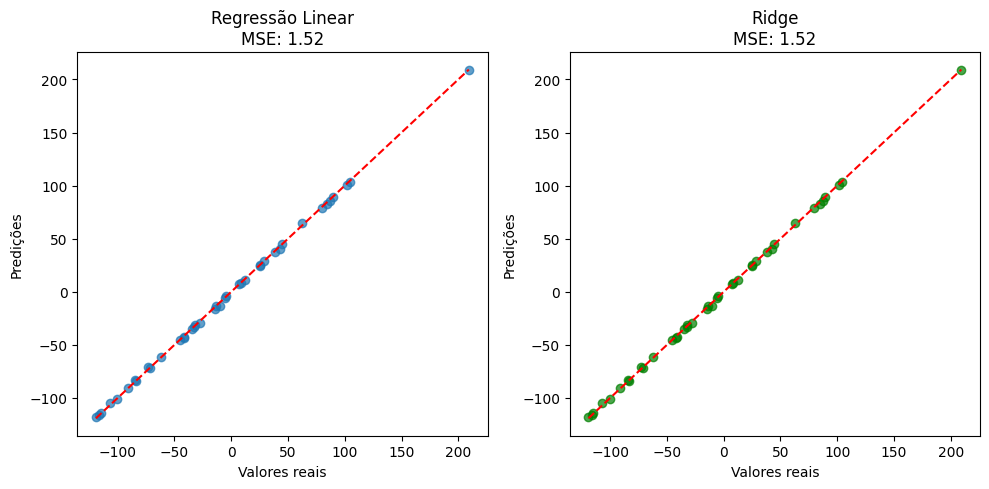

MSE Regressão Linear: 1.52
MSE Ridge: 1.52


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Gerar dados sintéticos com variáveis irrelevantes
X, y = make_regression(n_samples=200, n_features=50, n_informative=5, noise=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar os modelos
linear_reg = LinearRegression()
ridge_reg = Ridge(alpha=0, random_state=42)

# Treinar e prever com regressão linear tradicional
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Treinar e prever com Ridge
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Plotar os resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Regressão Linear\nMSE: {mse_linear:.2f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Ridge\nMSE: {mse_ridge:.2f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()

# Comparar MSE
print(f"MSE Regressão Linear: {mse_linear:.2f}")
print(f"MSE Ridge: {mse_ridge:.2f}")


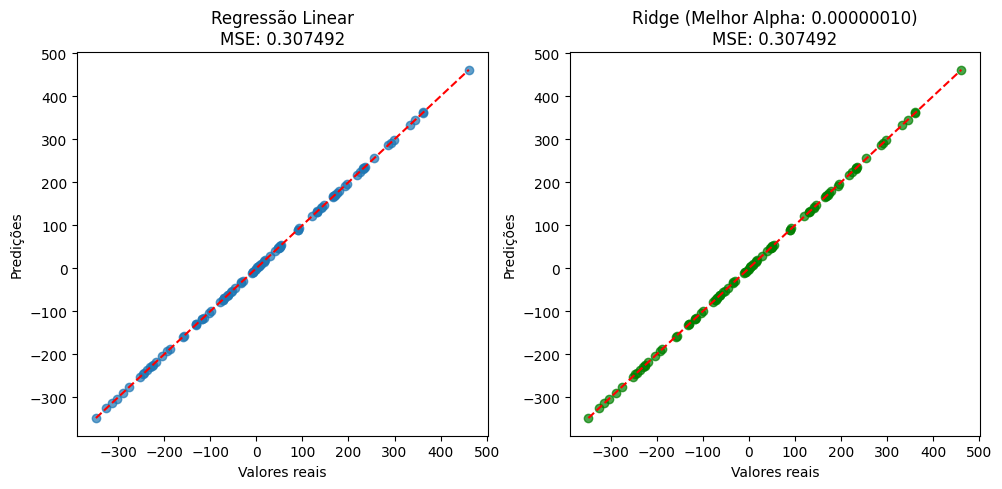

MSE Regressão Linear: 0.307492
MSE Ridge (Melhor Alpha: 0.00000010): 0.307492


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Gerar dados sintéticos com variáveis irrelevantes
X, y = make_regression(n_samples=500, n_features=100, n_informative=10, noise=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronizar os dados para melhor desempenho da regressão Ridge
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Inicializar os modelos
linear_reg = LinearRegression()

# Otimizar hiperparâmetro alpha para a regressão Ridge
param_grid = {'alpha': np.logspace(-6 , 6, 200)}  # Busca refinada
ridge_search = GridSearchCV(Ridge(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=10, n_jobs=-1)
ridge_search.fit(X_train, y_train)

# Melhor modelo Ridge
ridge_reg = Ridge(alpha=ridge_search.best_params_['alpha'], random_state=42)
ridge_reg.fit(X_train, y_train)

# Treinar e prever com regressão linear tradicional
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Prever com o melhor modelo Ridge
y_pred_ridge = ridge_reg.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Plotar os resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Regressão Linear\nMSE: {mse_linear:.6f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Ridge (Melhor Alpha: {ridge_search.best_params_["alpha"]:.8f})\nMSE: {mse_ridge:.6f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()

# Comparar MSE
print(f"MSE Regressão Linear: {mse_linear:.6f}")
print(f"MSE Ridge (Melhor Alpha: {ridge_search.best_params_['alpha']:.8f}): {mse_ridge:.6f}")


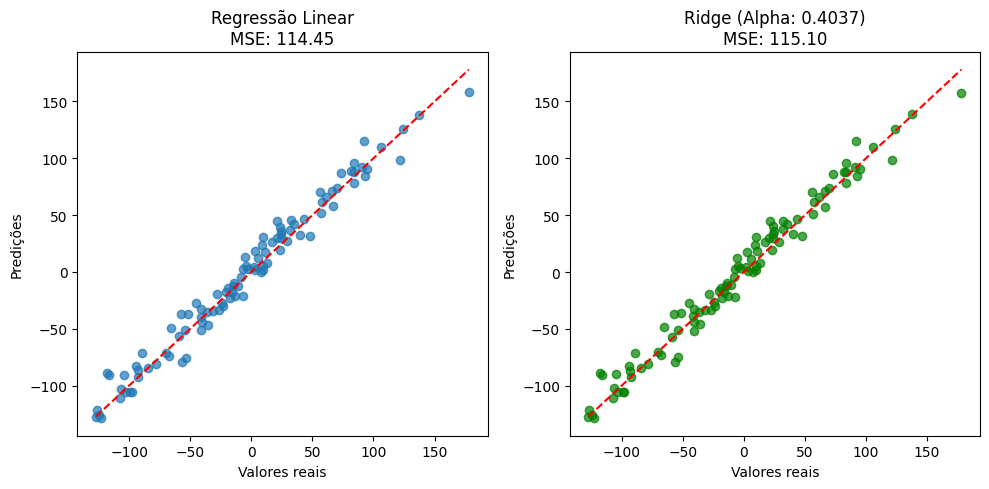

MSE Regressão Linear: 114.45
MSE Ridge: 115.10 (melhor alpha: 0.4037)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Simular um conjunto de dados com colinearidade
X, y = make_regression(n_samples=500, n_features=10, n_informative=5, noise=10, random_state=42)

# Criar variáveis correlacionadas artificialmente
X = np.hstack((X, X[:, :3] * 0.8 + np.random.normal(scale=0.1, size=(500, 3))))  # Adicionando colinearidade

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Inicializar e treinar a Regressão Linear
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Ajustar hiperparâmetro de Ridge para minimizar erro
param_grid = {'alpha': np.logspace(-3, 3, 100)}
ridge_search = GridSearchCV(Ridge(), param_grid, scoring='neg_mean_squared_error', cv=10, n_jobs=-1)
ridge_search.fit(X_train, y_train)

# Treinar o melhor modelo Ridge
ridge_reg = Ridge(alpha=ridge_search.best_params_['alpha'])
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Comparar resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Regressão Linear\nMSE: {mse_linear:.2f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Ridge (Alpha: {ridge_search.best_params_["alpha"]:.4f})\nMSE: {mse_ridge:.2f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()

# Imprimir os erros para comparação
print(f"MSE Regressão Linear: {mse_linear:.2f}")
print(f"MSE Ridge: {mse_ridge:.2f} (melhor alpha: {ridge_search.best_params_['alpha']:.4f})")


### Aplicando Ridge e comparando com a regressão linear, onde Ridge deve ser menor que a linear

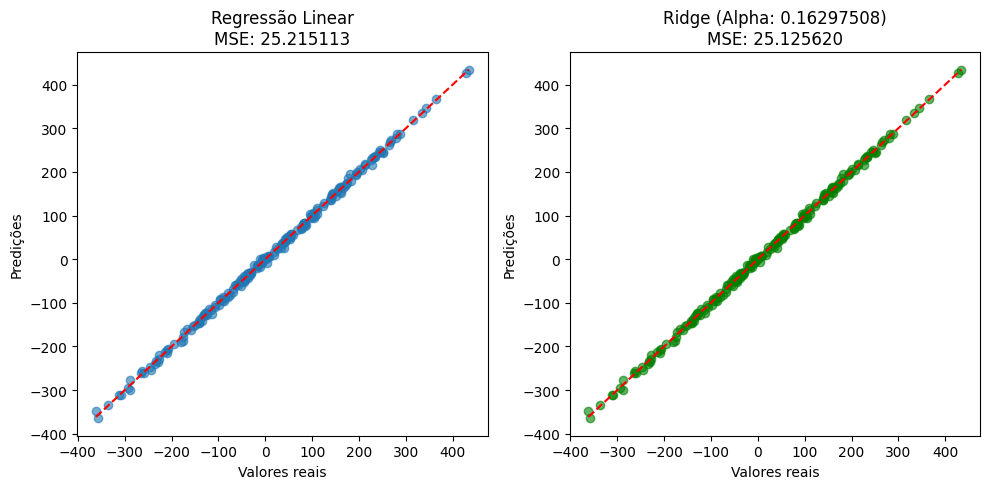

MSE Regressão Linear: 25.215113
MSE Ridge: 25.125620 (melhor alpha: 0.16297508)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Simular um conjunto de dados com colinearidade
X, y = make_regression(n_samples=1000, n_features=50, n_informative=10, noise=5, random_state=42)

# Criar variáveis correlacionadas artificialmente
X = np.hstack((X, X[:, :5] * 0.9 + np.random.normal(scale=0.1, size=(1000, 5))))  # Adicionando colinearidade

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Inicializar e treinar a Regressão Linear
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Ajustar hiperparâmetro de Ridge para minimizar erro
param_grid = {'alpha': np.logspace(-6, 6, 100)}
ridge_search = GridSearchCV(Ridge(), param_grid, scoring='neg_mean_squared_error', cv=20, n_jobs=-1)
ridge_search.fit(X_train, y_train)

# Treinar o melhor modelo Ridge
ridge_reg = Ridge(alpha=ridge_search.best_params_['alpha'])
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Comparar resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Regressão Linear\nMSE: {mse_linear:.6f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title(f'Ridge (Alpha: {ridge_search.best_params_["alpha"]:.8f})\nMSE: {mse_ridge:.6f}')
plt.xlabel('Valores reais')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()

# Imprimir os erros para comparação
print(f"MSE Regressão Linear: {mse_linear:.6f}")
print(f"MSE Ridge: {mse_ridge:.6f} (melhor alpha: {ridge_search.best_params_['alpha']:.8f})")

### Realizar um estudo de regressão linear com AutoML

In [ ]:
!pip install auto-sklearn
!pip install flaml
!pip install h2o

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,21 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,6 days
H2O_cluster_name:,H2O_from_python_unknownUser_xiuoqe
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
H2O session _sid_b8dc closed.
MSE H2O AutoML: 101.5265


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
<ipython-input-59-7dec9a4ac058>:27: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


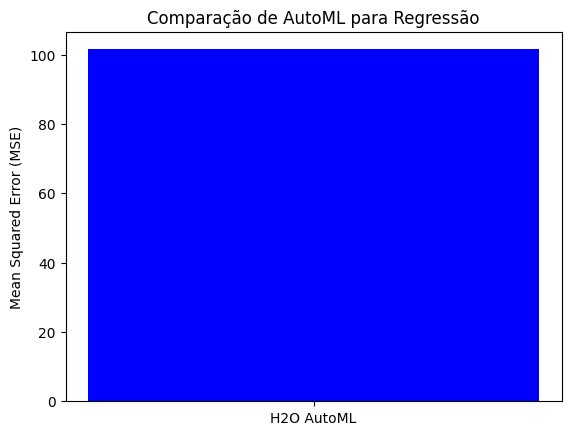

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Gerando um conjunto de dados sintético
X, y = make_regression(n_samples=500, n_features=20, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# H2O AutoML
import h2o
from h2o.automl import H2OAutoML

h2o.init()
train_df = h2o.H2OFrame(pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])]))
train_df['target'] = h2o.H2OFrame(y_train)
test_df = h2o.H2OFrame(pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])]))
test_df['target'] = h2o.H2OFrame(y_test)

aml = H2OAutoML(max_models=20, seed=42)
aml.train(y='target', training_frame=train_df)
preds_h2o = aml.leader.predict(test_df).as_data_frame().values.flatten()
mse_h2o = mean_squared_error(y_test, preds_h2o)

h2o.shutdown(prompt=False)

# Exibir Resultados
print(f"MSE H2O AutoML: {mse_h2o:.4f}")

# Comparação gráfica
models = ['H2O AutoML']
mse_values = [mse_h2o]
plt.bar(models, mse_values, color=['blue', 'orange', 'green'])
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Comparação de AutoML para Regressão')
plt.show()

# **Aplicações de Regressão Linear na Engenharia de Computação - Aula 9 (Parte 3)**

### Refazer a questão da aula anterior

In [ ]:
!pip install ipywidgets

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Cria um slider que varia de 0 a 10
slider = widgets.IntSlider(
    value=5,
    min=0,
    max=10,
    step=1,
    description='Valor:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# Exibe o slider
display(slider)

# Define uma função para ser executada quando o valor do slider muda
def on_value_change(change):
    print(f'Novo valor: {change["new"]}')

# Observa mudanças no valor do slider e chama a função on_value_change
slider.observe(on_value_change, names='value')

IntSlider(value=5, continuous_update=False, description='Valor:', max=10)

Novo valor: 6


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Cria uma caixa de seleção com opções
dropdown = widgets.Dropdown(
    options=['Opção 1', 'Opção 2', 'Opção 3', 'Opção 4'],
    value='Opção 1',
    description='Escolha:',
)

# Exibe a caixa de seleção
display(dropdown)

# Define uma função para ser executada quando a opção muda
def on_change(change):
    print(f'Opção selecionada: {change["new"]}')

# Observa mudanças na opção selecionada e chama a função on_change
dropdown.observe(on_change, names='value')

Dropdown(description='Escolha:', options=('Opção 1', 'Opção 2', 'Opção 3', 'Opção 4'), value='Opção 1')

Opção selecionada: Opção 4


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Cria um botão
button = widgets.Button(description="Clique aqui")

# Exibe o botão
display(button)

# Define uma função para ser executada quando o botão é clicado
def on_click(b):
    print("Botão clicado!")

# Associa a função on_click ao evento de clique do botão
button.on_click(on_click)

Button(description='Clique aqui', style=ButtonStyle())

Botão clicado!
Botão clicado!
Botão clicado!


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Cria uma caixa de texto
text = widgets.Text(
    value='Digite aqui',
    placeholder='Digite algo',
    description='Texto:',
    disabled=False
)

# Exibe a caixa de texto
display(text)

# Define uma função para ser executada quando o texto muda
def on_submit(change):
    print(f'Texto inserido: {change["new"]}')

# Observa mudanças no texto e chama a função on_submit
text.observe(on_submit, names='value')

Text(value='Digite aqui', description='Texto:', placeholder='Digite algo')

Texto inserido: Digite aquia
Texto inserido: Digite aquian
Texto inserido: Digite aquiand
Texto inserido: Digite aquiandre
Texto inserido: Digite aquiandreia
Texto inserido: 


In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Cria uma caixa de seleção com múltiplas opções
select_multiple = widgets.SelectMultiple(
    options=['Opção 1', 'Opção 2', 'Opção 3', 'Opção 4', 'Opção 5'],
    value=['Opção 1', 'Opção 3'],
    rows=5,
    description='Selecione:',
    disabled=False
)

# Exibe a caixa de seleção
display(select_multiple)

# Define uma função para ser executada quando a seleção muda
def on_change(change):
    print(f'Opções selecionadas: {change["new"]}')

# Observa mudanças na seleção e chama a função on_change
select_multiple.observe(on_change, names='value')

SelectMultiple(description='Selecione:', index=(0, 2), options=('Opção 1', 'Opção 2', 'Opção 3', 'Opção 4', 'O…

Opções selecionadas: ('Opção 1',)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.linear_model import LinearRegression

# Gerando dados aleatórios
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2

# Criando o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Função para atualizar o gráfico com base no valor do slider
def update_plot(slope):
    plt.scatter(X, y, color='blue', label='Dados')
    x_line = np.array([0, 10]).reshape(-1, 1)
    y_line = slope * x_line + model.intercept_
    plt.plot(x_line, y_line, color='red', label='Regressão (slope = {})'.format(slope))
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Regressão Linear com Slider')
    plt.legend()
    plt.show()

# Criando o slider
slope_slider = widgets.FloatSlider(
    value=model.coef_[0][0],
    min=0,
    max=5,
    step=0.1,
    description='Inclinação (Slope):',
)

# Chamando a função update_plot interativamente com o slider
widgets.interactive(update_plot, slope=slope_slider)

interactive(children=(FloatSlider(value=1.9080453545753935, description='Inclinação (Slope):', max=5.0), Outpu…

# **Aula 10**

### Fazer os gráficos baseados no arquivo em csv

<ipython-input-2-68b5ce98830d>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Alloy class', y='Hardness (HV)', data=df, palette='Set3')  # Cores diferentes com 'palette'


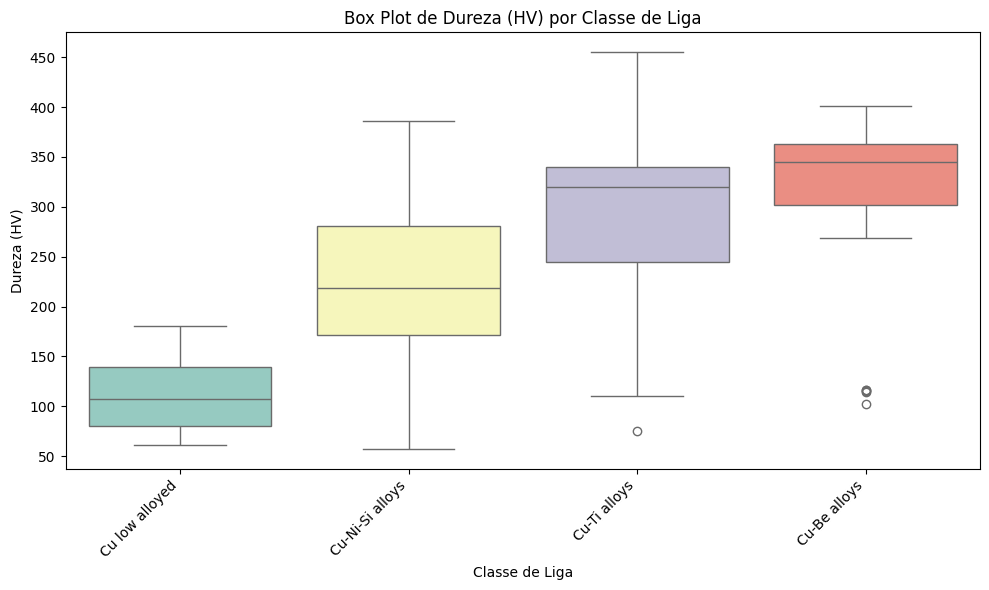

,Mediana,Quartis,Média
Alloy class,,,
Cu low alloyed,107.0,107.0,110.527473
Cu-Be alloys,344.5,344.5,314.571429
Cu-Ni-Si alloys,219.0,219.0,222.606792
Cu-Ti alloys,320.0,320.0,295.276923


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ler o arquivo CSV com a codificação correta e definir o delimitador
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')  # Adicionando delimiter=';'

# Criar o box plot
plt.figure(figsize=(10, 6))  # Ajustar tamanho da figura
sns.boxplot(x='Alloy class', y='Hardness (HV)', data=df, palette='Set3')  # Cores diferentes com 'palette'
plt.title('Box Plot de Dureza (HV) por Classe de Liga')
plt.xlabel('Classe de Liga')
plt.ylabel('Dureza (HV)')
plt.xticks(rotation=45, ha='right')  # Rotacionar os rótulos do eixo x
plt.tight_layout()  # Ajustar o layout
plt.show()

# Calcular estatísticas descritivas para cada categoria
summary_stats = df.groupby('Alloy class')['Hardness (HV)'].agg(['median', 'quantile', 'mean'])

# Renomear as colunas
summary_stats = summary_stats.rename(columns={'median': 'Mediana', 'quantile': 'Quartis', 'mean': 'Média'})

# Exibir a tabela
display(summary_stats)

<ipython-input-10-58769b7fc6d4>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Alloy class', y='Hardness (HV)', data=df, palette='Set3', order=order)  # Usar order


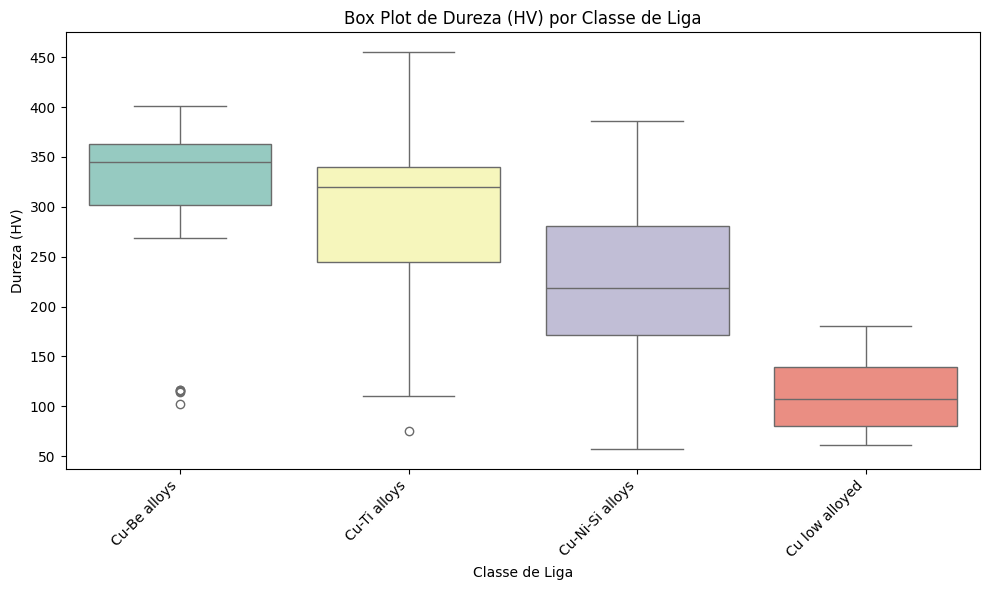

,Mediana,Quartis,Média
Alloy class,,,
Cu-Ti alloys,320.0,320.0,295.276923
Cu-Ni-Si alloys,219.0,219.0,222.606792
Cu-Be alloys,344.5,344.5,314.571429
Cu low alloyed,107.0,107.0,110.527473


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ler o arquivo CSV com a codificação correta e definir o delimitador
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')  # Adicionando delimiter=';'

# Criar o box plot com ordem invertida
order = df['Alloy class'].unique()[::-1]  # Inverter a ordem das categorias

plt.figure(figsize=(10, 6))  # Ajustar tamanho da figura
sns.boxplot(x='Alloy class', y='Hardness (HV)', data=df, palette='Set3', order=order)  # Usar order
plt.title('Box Plot de Dureza (HV) por Classe de Liga')
plt.xlabel('Classe de Liga')
plt.ylabel('Dureza (HV)')
plt.xticks(rotation=45, ha='right')  # Rotacionar os rótulos do eixo x
plt.tight_layout()  # Ajustar o layout
plt.show()

# Calcular estatísticas descritivas para cada categoria
summary_stats = df.groupby('Alloy class')['Hardness (HV)'].agg(['median', 'quantile', 'mean'])

# Renomear as colunas
summary_stats = summary_stats.rename(columns={'median': 'Mediana', 'quantile': 'Quartis', 'mean': 'Média'})

# Inverter a ordem das linhas na tabela
summary_stats = summary_stats.reindex(index=summary_stats.index[::-1])  # Inverter ordem


# Exibir a tabela
display(summary_stats)

<ipython-input-11-e7ed5aaaa095>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Alloy class', y='Ultimate tensile strength (MPa)', data=df, palette='Set3', order=order)  # Usar order e nova propriedade


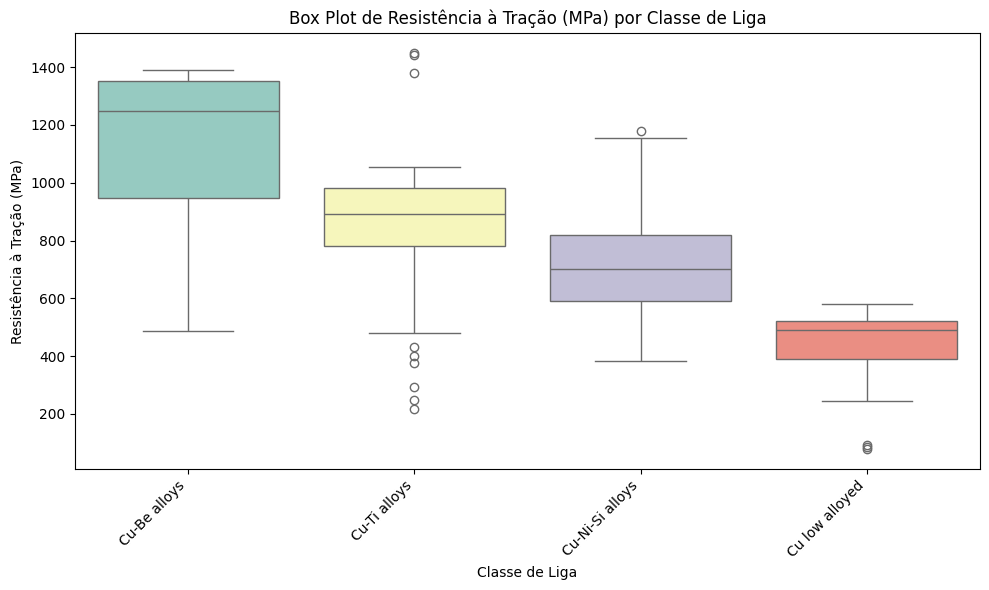

,Mediana,Quartis,Média
Alloy class,,,
Cu-Ti alloys,892.0,892.0,853.924528
Cu-Ni-Si alloys,700.5,700.5,717.151786
Cu-Be alloys,1247.5,1247.5,1104.666667
Cu low alloyed,490.0,490.0,444.850575


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ler o arquivo CSV com a codificação correta e definir o delimitador
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')  # Adicionando delimiter=';'

# Criar o box plot com ordem invertida
order = df['Alloy class'].unique()[::-1]  # Inverter a ordem das categorias

plt.figure(figsize=(10, 6))  # Ajustar tamanho da figura
sns.boxplot(x='Alloy class', y='Ultimate tensile strength (MPa)', data=df, palette='Set3', order=order)  # Usar order e nova propriedade
plt.title('Box Plot de Resistência à Tração (MPa) por Classe de Liga') # Alterar título
plt.xlabel('Classe de Liga')
plt.ylabel('Resistência à Tração (MPa)') # Alterar rótulo do eixo y
plt.xticks(rotation=45, ha='right')  # Rotacionar os rótulos do eixo x
plt.tight_layout()  # Ajustar o layout
plt.show()

# Calcular estatísticas descritivas para cada categoria
summary_stats = df.groupby('Alloy class')['Ultimate tensile strength (MPa)'].agg(['median', 'quantile', 'mean']) # Alterar propriedade

# Renomear as colunas
summary_stats = summary_stats.rename(columns={'median': 'Mediana', 'quantile': 'Quartis', 'mean': 'Média'})

# Inverter a ordem das linhas na tabela
summary_stats = summary_stats.reindex(index=summary_stats.index[::-1])  # Inverter ordem


# Exibir a tabela
display(summary_stats)

### Fazer uma matriz de correlação baseado no arquivo em csv

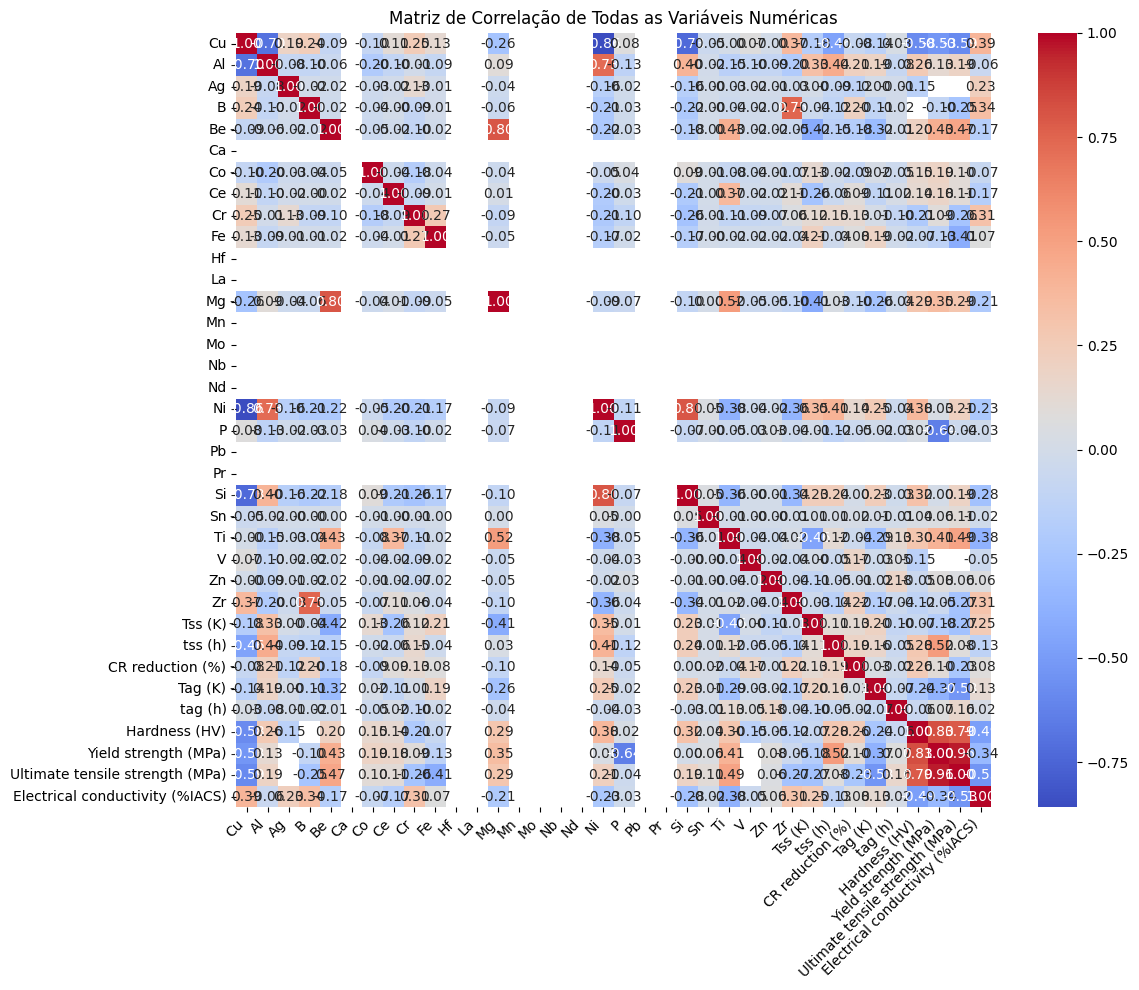

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# Remover colunas não numéricas para correlação
numeric_df = df.select_dtypes(include=['number'])

# Calcular a matriz de correlação
corr_matrix = numeric_df.corr()

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(12, 10))  # Ajustar tamanho da figura
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação de Todas as Variáveis Numéricas')
plt.xticks(rotation=45, ha='right')  # Rotacionar os rótulos do eixo x
plt.tight_layout()
plt.show()

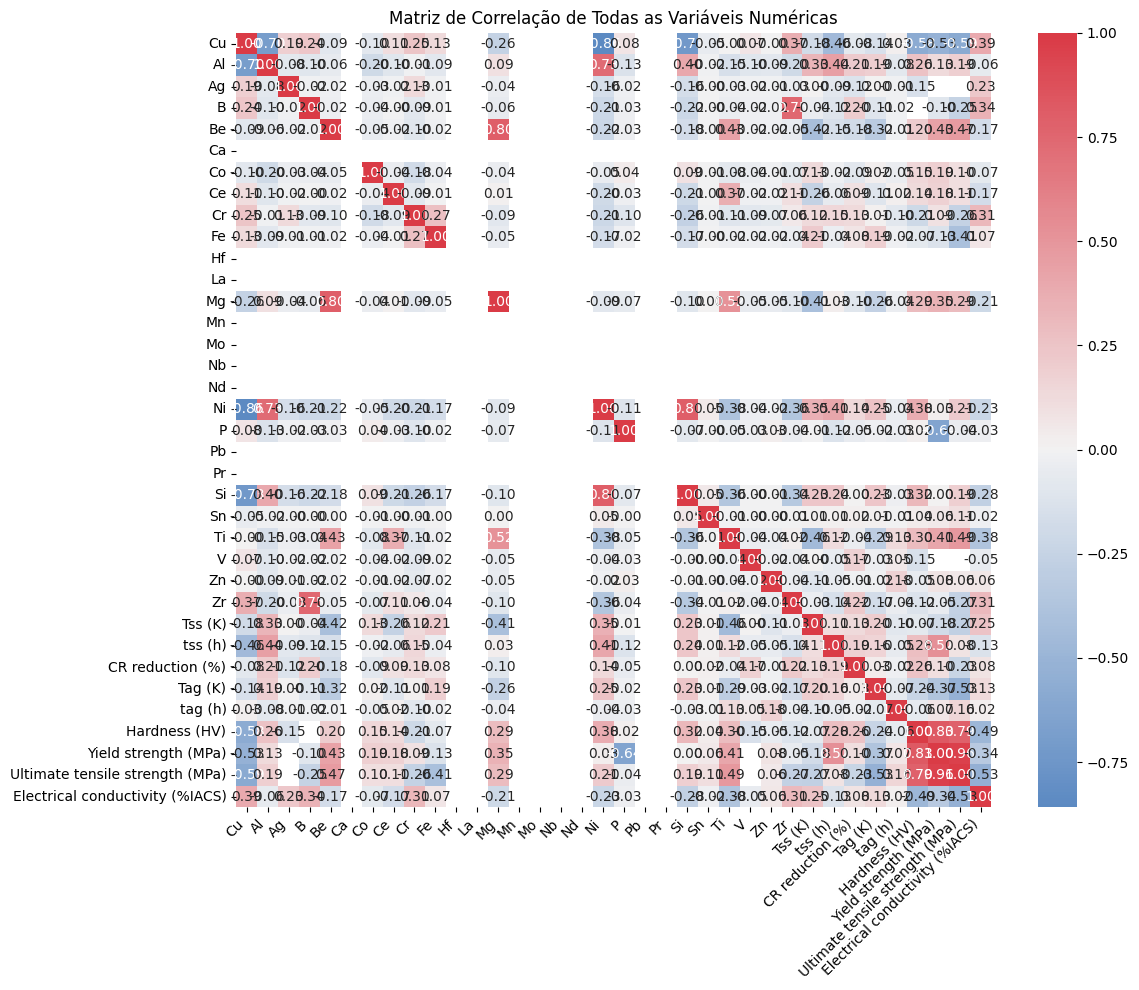

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# Substituir espaços vazios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Remover colunas não numéricas para correlação
numeric_df = df.select_dtypes(include=['number'])

# Calcular a matriz de correlação
corr_matrix = numeric_df.corr()

# Criar a paleta de cores divergente
cmap = sns.diverging_palette(250, 10, as_cmap=True)  # Azul para 0, vermelho para 1

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", center=0)  # Centralizar em 0
plt.title('Matriz de Correlação de Todas as Variáveis Numéricas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

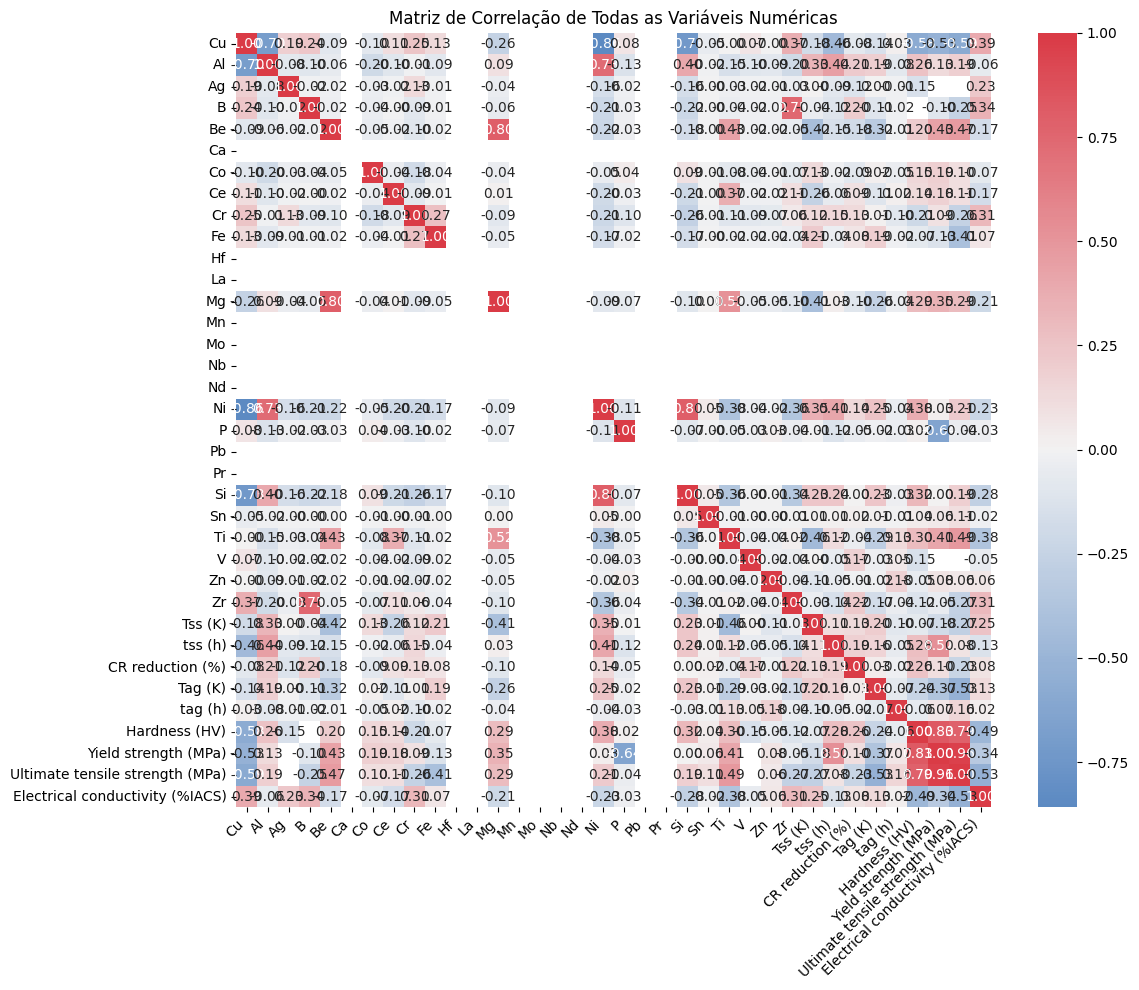

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# Substituir espaços vazios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Remover colunas não numéricas para correlação
numeric_df = df.select_dtypes(include=['number'])

# Remover linhas e colunas com valores NaN
numeric_df = numeric_df.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Calcular a matriz de correlação
corr_matrix = numeric_df.corr()

# Criar a paleta de cores divergente
cmap = sns.diverging_palette(250, 10, as_cmap=True)  # Azul para 0, vermelho para 1

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", center=0)  # Centralizar em 0
plt.title('Matriz de Correlação de Todas as Variáveis Numéricas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

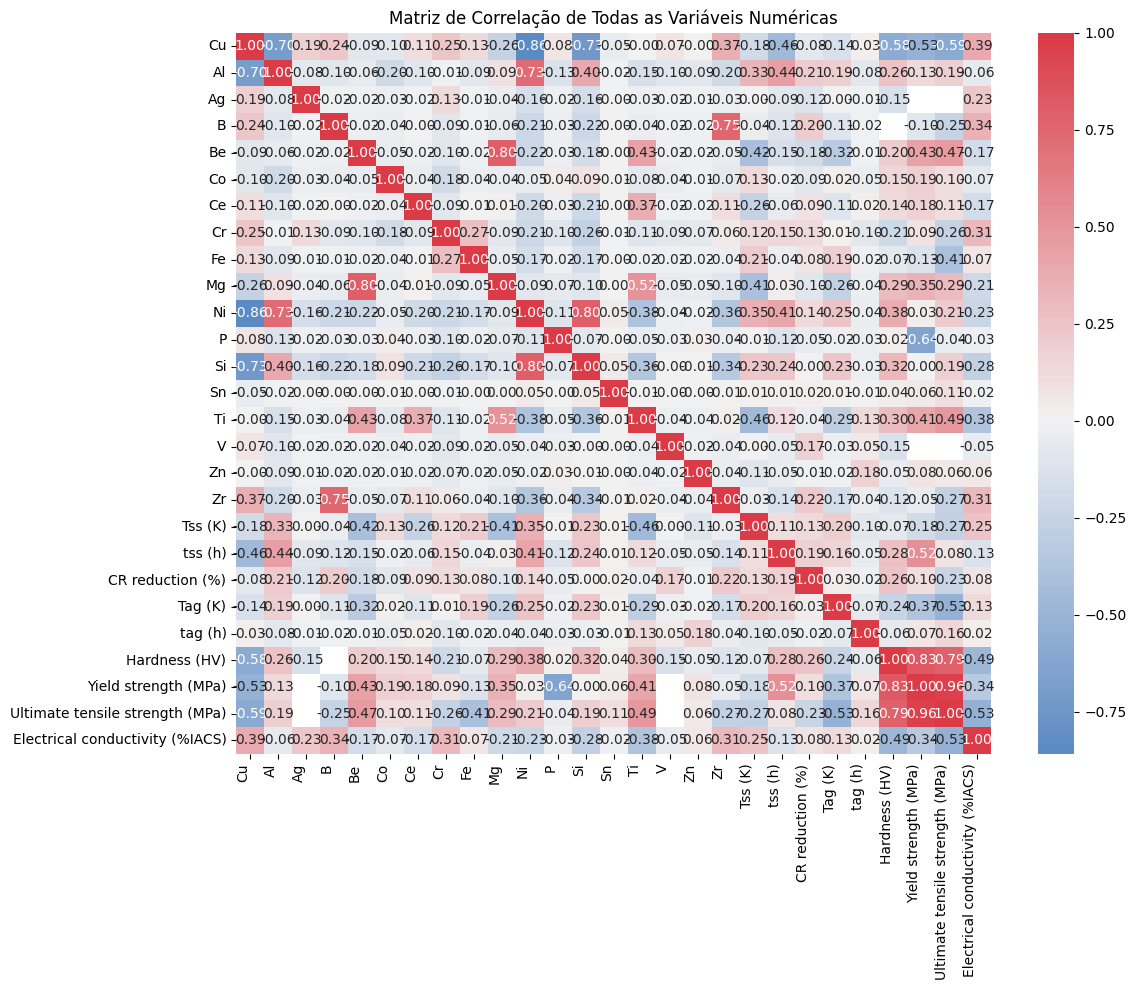

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# Substituir espaços vazios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Remover linhas com os elementos especificados
elements_to_remove = ['Hf', 'Mn', 'Mo', 'Nb', 'Nd', 'Pb', 'Pr','Ca']
df = df[~df['Alloy class'].isin(elements_to_remove)]

# Remover colunas com os elementos especificados
columns_to_remove = ['Hf', 'La', 'Mn', 'Mo', 'Nb', 'Nd', 'Pb', 'Pr','Ca']
df = df.drop(columns=columns_to_remove, errors='ignore')

# Remover colunas não numéricas para correlação
numeric_df = df.select_dtypes(include=['number'])

# Remover linhas e colunas com valores NaN
numeric_df = numeric_df.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Calcular a matriz de correlação
corr_matrix = numeric_df.corr()

# Criar a paleta de cores divergente
cmap = sns.diverging_palette(250, 10, as_cmap=True)  # Azul para 0, vermelho para 1

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", center=0)  # Centralizar em 0
plt.title('Matriz de Correlação de Todas as Variáveis Numéricas')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

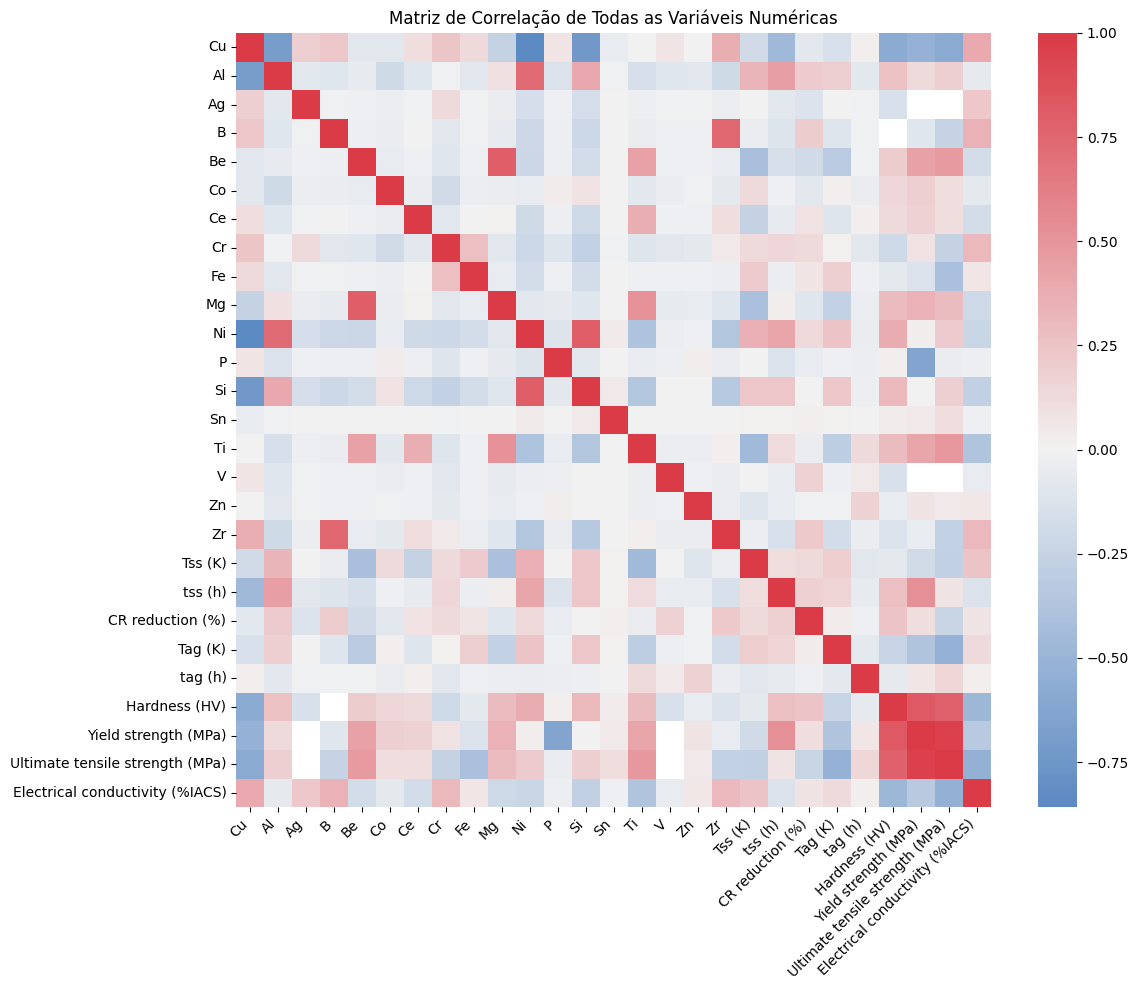

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# ... (código anterior para pré-processamento do DataFrame) ...

# Plotar a matriz de correlação como um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap=cmap, fmt=".2f", center=0)  # Mudança aqui
plt.title('Matriz de Correlação de Todas as Variáveis Numéricas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Fazer um gráfico de dispersão que compare duas propriedades

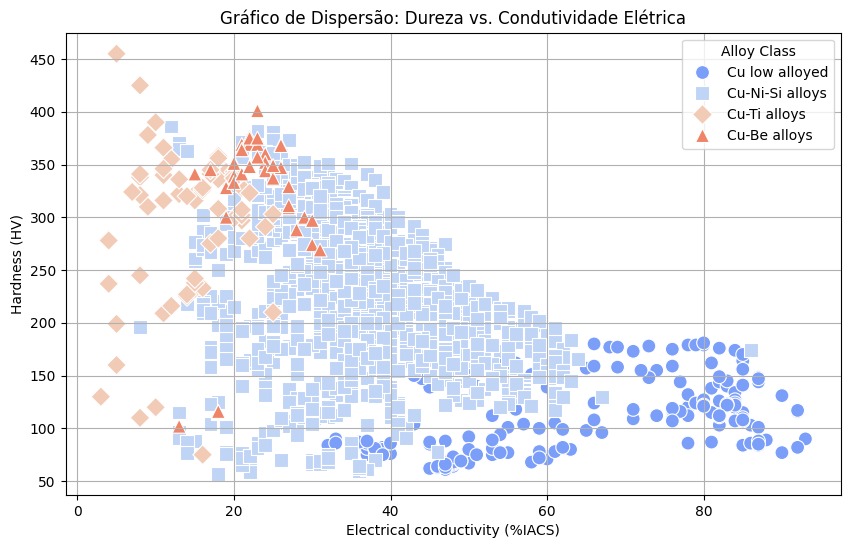

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# Substituir espaços vazios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Filtrar as ligas desejadas
ligas_desejadas = ["Cu low alloyed", "Cu-Ti alloys", "Cu-Ni-Si alloys", "Cu-Be alloys"]
df_filtrado = df[df['Alloy class'].isin(ligas_desejadas)]

# Criar o gráfico de dispersão com cores e formas
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Electrical conductivity (%IACS)',
    y='Hardness (HV)',
    hue='Alloy class',  # Define a cor pelo tipo de liga
    style='Alloy class',  # Define a forma pelo tipo de liga
    data=df_filtrado,
    palette='coolwarm',  # Paleta de cores como no mapa de calor
    markers=['o', 's', 'D', '^'],  # Diferentes formas para cada liga
    s=100  # Tamanho dos marcadores
)

plt.title('Gráfico de Dispersão: Dureza vs. Condutividade Elétrica')
plt.xlabel('Electrical conductivity (%IACS)')
plt.ylabel('Hardness (HV)')
plt.legend(title='Alloy Class')
plt.grid(True)
plt.show()

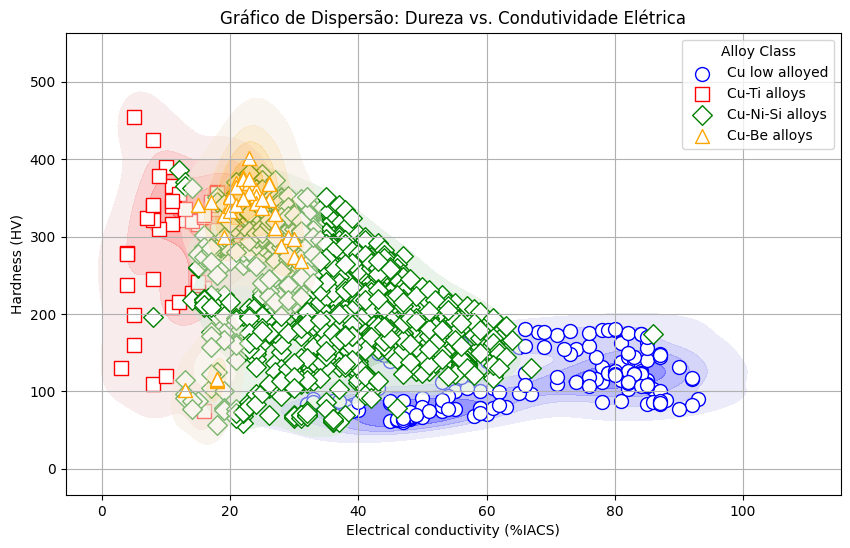

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carregar o arquivo CSV
df = pd.read_csv('Cu_alloys_database_2023_06_06.csv', encoding='latin1', delimiter=';')

# Substituir espaços vazios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Filtrar as ligas desejadas
ligas_desejadas = ["Cu low alloyed", "Cu-Ti alloys", "Cu-Ni-Si alloys", "Cu-Be alloys"]
df_filtrado = df[df['Alloy class'].isin(ligas_desejadas)]

# Remover linhas com valores NaN nas colunas 'Electrical conductivity (%IACS)' e 'Hardness (HV)'
df_filtrado = df_filtrado.dropna(subset=['Electrical conductivity (%IACS)', 'Hardness (HV)'])

# Criar o gráfico de dispersão com cores e formas, com gradiente de densidade
plt.figure(figsize=(10, 6))

# Definir cores e marcadores
colors = {'Cu low alloyed': 'blue', 'Cu-Ti alloys': 'red', 'Cu-Ni-Si alloys': 'green', 'Cu-Be alloys': 'orange'}
markers = {'Cu low alloyed': 'o', 'Cu-Ti alloys': 's', 'Cu-Ni-Si alloys': 'D', 'Cu-Be alloys': '^'}

# Plotar os pontos com cores apenas onde há concentração
for liga in ligas_desejadas:
    df_liga = df_filtrado[df_filtrado['Alloy class'] == liga]
    sns.kdeplot(
        x=df_liga['Electrical conductivity (%IACS)'],
        y=df_liga['Hardness (HV)'],
        fill=True,
        cmap=sns.light_palette(colors[liga], as_cmap=True),  # Cor da liga
        alpha=0.5,  # Transparência
        levels=5,  # Número de níveis de densidade
    )
    plt.scatter(
        x=df_liga['Electrical conductivity (%IACS)'],
        y=df_liga['Hardness (HV)'],
        marker=markers[liga],  # Marcador da liga
        color='white',  # Cor branca para pontos fora da concentração
        edgecolor=colors[liga],  # Borda na cor da liga
        s=100,  # Tamanho dos marcadores
        label=liga  # Adicionando label para a legenda
    )

plt.title('Gráfico de Dispersão: Dureza vs. Condutividade Elétrica')
plt.xlabel('Electrical conductivity (%IACS)')
plt.ylabel('Hardness (HV)')
plt.grid(True)

# Adicionando a legenda
plt.legend(title='Alloy Class', loc='best') # loc='best' para melhor posicionamento

plt.show()

# **Aula 11**

### Mudar as especificações e observar as alterações no gráfico

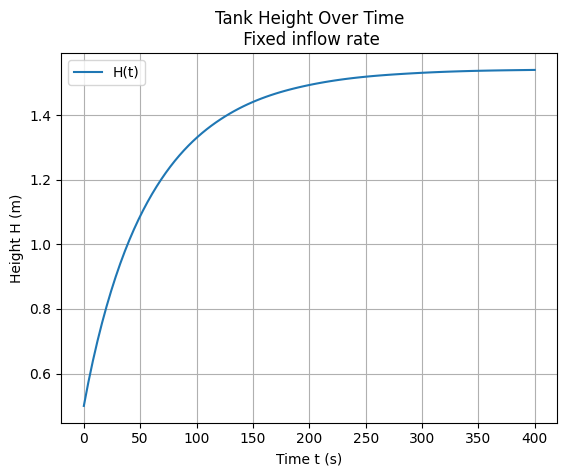

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define constants
Q1 = 34.77  # kg/s (constant inflow rate)
H0 = 0.5  # Initial height (m)

# Define the ODE
def dHdt(t, H):
    return -0.03564*np.sqrt(H)+1.2732*(10**-3)*Q1

# Initial condition
y0 = [H0]

# Time span for the simulation (0 to 400 seconds)
t_span = (0, 400)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
# support documentation
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
solution = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

# Plot the solution
plt.plot(solution.t, solution.y[0], label='H(t)')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n Fixed inflow rate')
plt.legend()
plt.grid(True)
plt.show()

https://colab.research.google.com/drive/1Ok0OEs1IfsIxgRd6_QavdMQUS6fy7ej7?usp=sharing (abrir este link para outras questões)

### Como a questão anterior, mudar os parâmetros e observar as mudanças no gráfico

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define constants
Q1 = 45.77  # kg/s (constant inflow rate)
H0 = 0.5    # Initial height (m)

# Define the ODE
def dHdt(t, H):
    return -0.03564*np.sqrt(H)+1.2732*(10**-3)*Q1

# Initial condition
y0 = [H0]

# Time span for the simulation (0 to 300 seconds)
t_span = (0, 300)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
# support documentation
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
solution = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

# calculate time constant RC
max_value = np.max(solution.y[0])
min_value = np.min(solution.y[0])
target_value = 0.635 * (max_value-min_value) + min_value
index = np.argmax(solution.y[0] >= target_value)
time_at_target = solution.t[index]
value_at_target = solution.y[0][index]

print(f"The variable reaches 63.5% of its maximum value at time: {time_at_target:.4f}")
print(f"63.5% of the range until from start value to its maximum value is: {value_at_target:.4f}")

The variable reaches 63.5% of its maximum value at time: 75.7576
63.5% of the range until from start value to its maximum value is: 1.8575


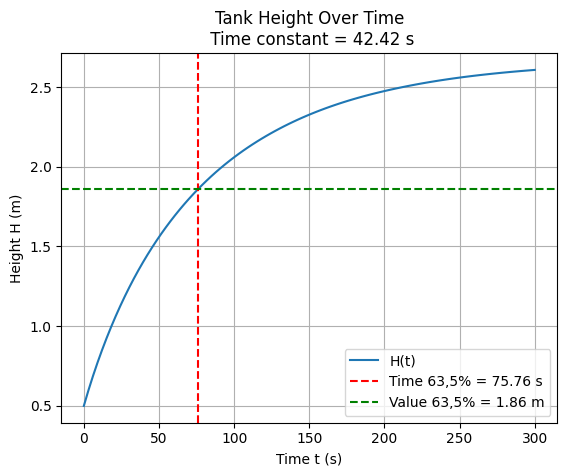

In [ ]:
# Plot the solution
plt.plot(solution.t, solution.y[0], label='H(t)')
plt.axvline(x=time_at_target, color='r', linestyle='--', label=f'Time 63,5% = {time_at_target:.2f} s')
plt.axhline(y=value_at_target, color='g', linestyle='--', label=f'Value 63,5% = {value_at_target:.2f} m')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n Time constant = 42.42 s')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# calculate time when y is 25% of maximum
max_value = np.max(solution.y[0])
min_value = np.min(solution.y[0])
ten_percent = 0.25 * (max_value-min_value) + min_value
index = np.argmax(solution.y[0] >= ten_percent)
time_at_ten_percent = solution.t[index]
value_at_ten_percent = solution.y[0][index]

print(f"The variable reaches 10% of its maximum value at time: {time_at_ten_percent:.4f} s")
print(f"10% of the range until from start value to its maximum value is: {value_at_ten_percent:.4f} m")

# calculate time when y is 90% of maximum
max_value = np.max(solution.y[0])
min_value = np.min(solution.y[0])
ten_percent = 0.90 * (max_value-min_value) + min_value
index = np.argmax(solution.y[0] >= ten_percent)
time_at_ninety_percent = solution.t[index]
value_at_ninety_percent = solution.y[0][index]

print(f"The variable reaches 90% of its maximum value at time: {time_at_ninety_percent:.4f} s")
print(f"90% of the range until from start value to its maximum value is: {value_at_ninety_percent:.4f} m")

print(f"The rise time is: {time_at_ninety_percent-time_at_ten_percent:.4f}")

The variable reaches 10% of its maximum value at time: 21.2121 s
10% of the range until from start value to its maximum value is: 1.0629 m
The variable reaches 90% of its maximum value at time: 172.7273 s
90% of the range until from start value to its maximum value is: 2.4049 m
The rise time is: 151.5152


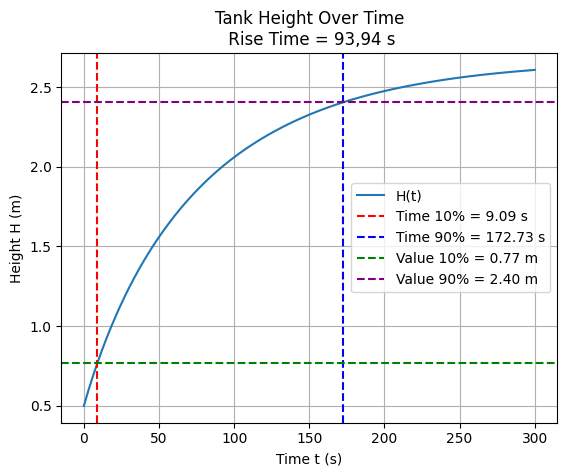

In [ ]:
# Plot the solution
plt.plot(solution.t, solution.y[0], label='H(t)')
plt.axvline(x=time_at_ten_percent, color='r', linestyle='--', label=f'Time 10% = {time_at_ten_percent:.2f} s')
plt.axvline(x=time_at_ninety_percent, color='b', linestyle='--', label=f'Time 90% = {time_at_ninety_percent:.2f} s')
plt.axhline(y=value_at_ten_percent, color='g', linestyle='--', label=f'Value 10% = {value_at_ten_percent:.2f} m')
plt.axhline(y=value_at_ninety_percent, color='purple', linestyle='--', label=f'Value 90% = {value_at_ninety_percent:.2f} m')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n Rise Time = 93,94 s')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
final_value = solution.y[0][-1]  # Get the final value
error_band = 0.07 * final_value  # ±2% error band
upper_bound = final_value + error_band
lower_bound = final_value - error_band

# Find the index where the output enters and stays within the error band
settling_index = np.argmax(np.logical_and(solution.y[0] >= lower_bound,
                                          solution.y[0] <= upper_bound))

# Get the corresponding time
settling_time = solution.t[settling_index]

print(f"Settling time: {settling_time:.4f} seconds")

Settling time: 181.8182 seconds


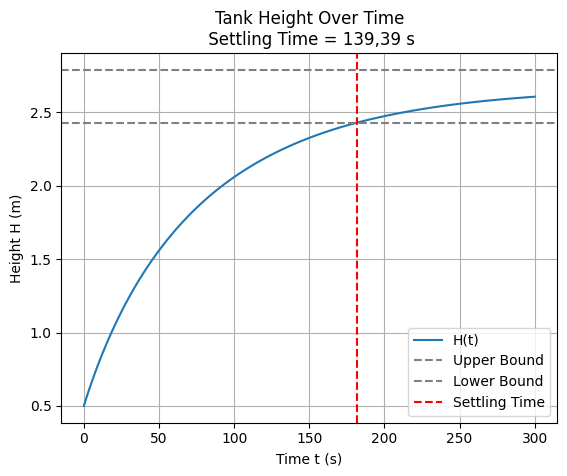

In [ ]:
# Plot the solution
plt.plot(solution.t, solution.y[0], label='H(t)')
plt.axhline(y=upper_bound, color='gray', linestyle='--', label='Upper Bound')
plt.axhline(y=lower_bound, color='gray', linestyle='--', label='Lower Bound')

# Add a vertical line for the settling time
plt.axvline(x=settling_time, color='red', linestyle='--', label='Settling Time')

plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n Settling Time = 139,39 s')
plt.legend()
plt.grid(True)
plt.show()

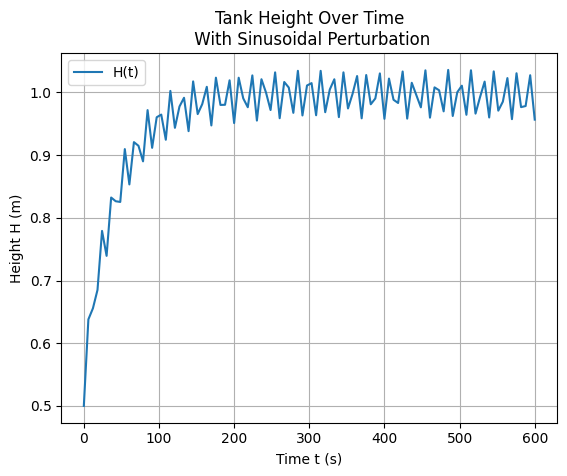

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define constants
Q1 = 34.77  # kg/s (constant inflow rate)
H0 = 0.5    # Initial height (m)

# Introduce instability:  A sinusoidal perturbation to the inflow rate
amplitude = 20 # Adjust the amplitude of the perturbation
frequency = 0.1 # Adjust the frequency of the perturbation

# Define the ODE with instability
def dHdt(t, H):
    perturbation = amplitude * np.sin(2 * np.pi * frequency * t)
    return -0.0443*np.sqrt(H) + 1.2732*(10**-3) * (Q1 + perturbation)

# Initial condition
y0 = [H0]

# Time span for the simulation (0 to 600 seconds)
t_span = (0, 600)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
solution = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

# Plot the solution
plt.plot(solution.t, solution.y[0], label='H(t)')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n With Sinusoidal Perturbation')
plt.legend()
plt.grid(True)
plt.show()


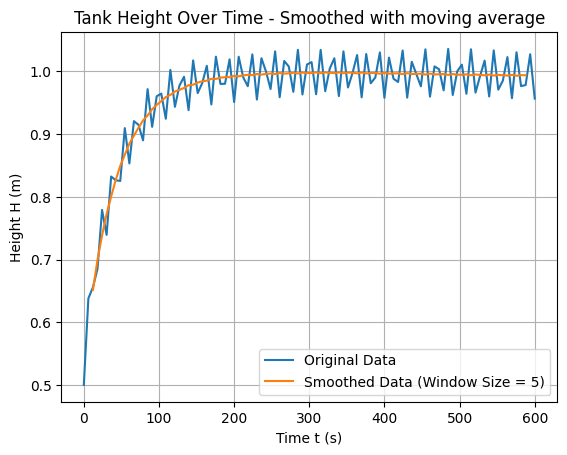

In [ ]:
import numpy as np

# Assuming 'solution.y[0]' contains the height data from the previous code
# Replace this with your actual data if it's stored differently.
# Example:  solution.y[0] = np.array([1, 2, 3, 4, 5])
# In a real scenario, you will replace the next line with your solution.y[0] data

# Example data for demonstration (replace with your actual data)
height_data = solution.y[0]


# Apply a moving average filter
window_size = 5 # Adjust window size as needed
smoothed_data = np.convolve(height_data, np.ones(window_size), 'valid') / window_size

# Plotting (optional but recommended)
plt.plot(solution.t, solution.y[0], label='Original Data')
plt.plot(solution.t[int(window_size/2):len(smoothed_data)+int(window_size/2)], smoothed_data, label=f'Smoothed Data (Window Size = {window_size})')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time - Smoothed with moving average')
plt.legend()
plt.grid(True)
plt.show()


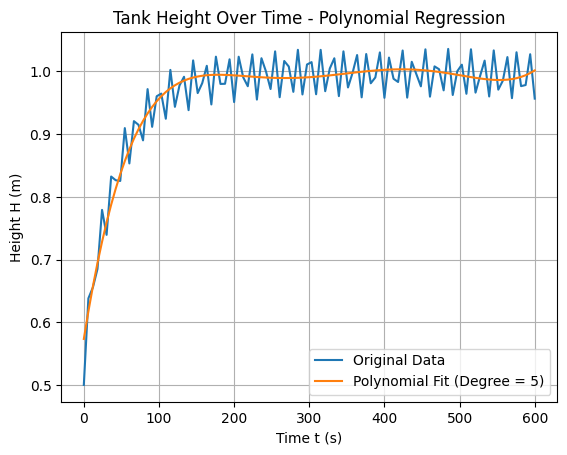

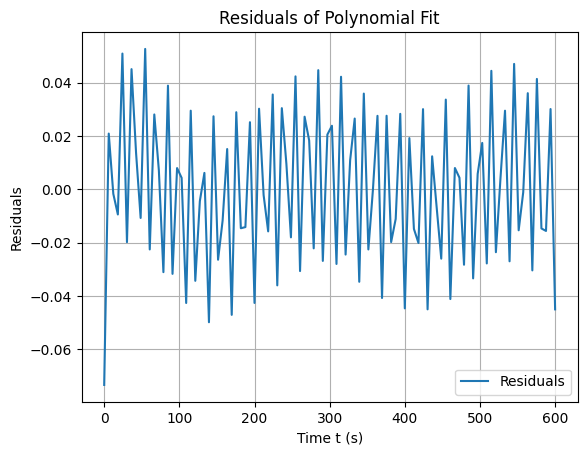

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# ... (Your existing code for the ODE solution with perturbation) ...

# Assuming 'solution.y[0]' contains the height data from the previous code
# Replace this with your actual data if it's stored differently.

# Example data for demonstration (replace with your actual data)
height_data = solution.y[0]
time_data = solution.t

# Fit a polynomial to the data
degree = 5  # Adjust the degree of the polynomial as needed
p = Polynomial.fit(time_data, height_data, degree)

# Generate points for the fitted polynomial curve
polynomial_fit = p(time_data)

# Plotting (optional but recommended)
plt.plot(time_data, height_data, label='Original Data')
plt.plot(time_data, polynomial_fit, label=f'Polynomial Fit (Degree = {degree})')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time - Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()

# Calculate the difference between the original and fitted data (residuals)
residuals = height_data - polynomial_fit

# Plot the residuals
plt.plot(time_data, residuals, label='Residuals')
plt.xlabel('Time t (s)')
plt.ylabel('Residuals')
plt.title('Residuals of Polynomial Fit')
plt.legend()
plt.grid(True)
plt.show()


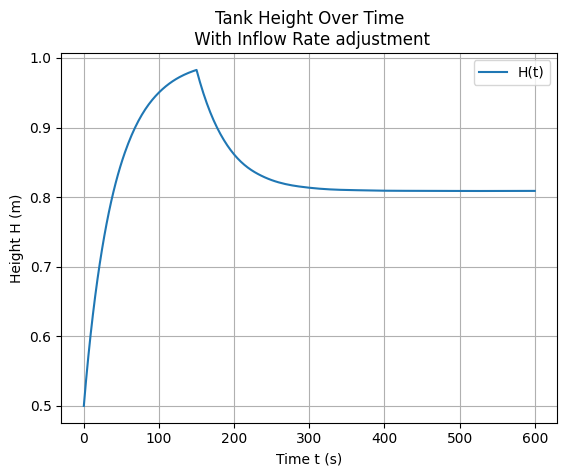

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define constants
Q1 = 34.77  # kg/s (constant inflow rate)
H0 = 0.5    # Initial height (m)

# Define the ODE with instability
def dHdt(t, H):
    return -0.0443*np.sqrt(H) + 1.2732*(10**-3) * Q1

# Initial condition
y0 = [H0]

# Time span for the simulation (0 to 150 seconds)
t_span = (0, 150)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
solution_1 = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

# Define constants
Q1 = 34.77 * 0.9  # kg/s (10% decrease in inflow rate)
H0 = solution_1.y[0][-1]    #last value from previous simulation (m)

# Define the ODE with instability
def dHdt(t, H):
    return -0.0443*np.sqrt(H) + 1.2732*(10**-3) * Q1

# Initial condition
y0 = [H0]

# Time span for the simulation (150 to 600 seconds)
t_span = (150, 600)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
solution_2 = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

solution = np.concatenate((solution_1.y[0], solution_2.y[0]))
t = np.concatenate((solution_1.t, solution_2.t))

# Plot the solution
plt.plot(t, solution, label='H(t)')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n With Inflow Rate adjustment')
plt.legend()
plt.grid(True)
plt.show()


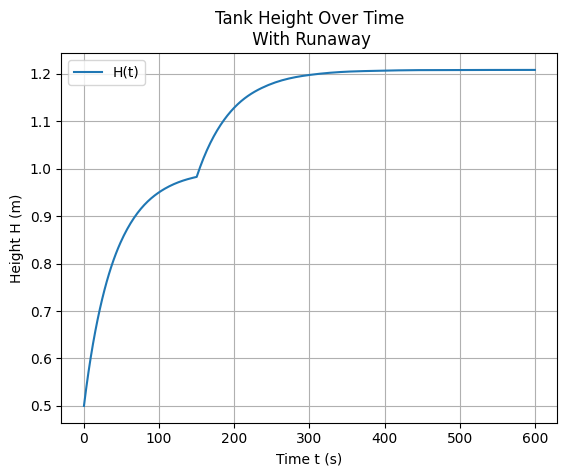

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define constants
Q1 = 34.77  # kg/s (constant inflow rate)
H0 = 0.5    # Initial height (m)

# Define the ODE with instability
def dHdt(t, H):
    return -0.0443*np.sqrt(H) + 1.2732*(10**-3) * Q1

# Initial condition
y0 = [H0]

# Time span for the simulation (0 to 150 seconds)
t_span = (0, 150)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
solution_1 = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

# Define constants
Q1 = 34.77 * 1.1  # kg/s (10% increase in inflow rate)
H0 = solution_1.y[0][-1]    #last value from previous simulation (m)

# Define the ODE with instability
def dHdt(t, H):
    return -0.0443*np.sqrt(H) + 1.2732*(10**-3) * Q1

# Initial condition
y0 = [H0]

# Time span for the simulation (150 to 600 seconds)
t_span = (150, 600)
t_eval = np.linspace(*t_span, 100)

# Solve the ODE
solution_2 = solve_ivp(dHdt, t_span, y0, t_eval=t_eval)

solution = np.concatenate((solution_1.y[0], solution_2.y[0]))
t = np.concatenate((solution_1.t, solution_2.t))

# Plot the solution
plt.plot(t, solution, label='H(t)')
plt.xlabel('Time t (s)')
plt.ylabel('Height H (m)')
plt.title('Tank Height Over Time\n With Runaway')
plt.legend()
plt.grid(True)
plt.show()


# **Aula 12 - GPS**

In [ ]:
pip install folium

In [ ]:
import folium

# Criar um mapa centrado em porto rico
portorico_mapa_0 = folium.Map(location=[18.181117069103585, -66.51561200125315], zoom_start=10, tiles="OpenStreetMap")

# Mostrar o mapa
portorico_mapa_0

### Atividade 2 - Criar marcadores de distância

In [ ]:
import folium
from geopy.distance import geodesic

# Criar um mapa centrado em Le Mans
lemans_mapa_2 = folium.Map(location=[48.005780375425985, 0.20160246335018384], zoom_start=8, tiles="OpenStreetMap")

# Coordenadas de Le Mans & Torre Eiffel
# Diretamente pela latitude e longitude obtidas pelo link no Google Maps
lmans_lat, lmans_lon = 48.005780375425985, 0.20160246335018384
eiffel_lat, eiffel_lon = 48.85837822580505, 2.294525896100113

#Calcular distância
lmans_coords = (lmans_lat, lmans_lon)
eiffel_coords = (eiffel_lat, eiffel_lon)
distancia = geodesic(lmans_coords, eiffel_coords).km
print(f"A distância entre Le Mans e a Torre Eiffel é de {distancia:.2f} km")

# Adicionar marcadores para a Le Mans e Torre Eiffel
folium.Marker([lmans_lat, lmans_lon], popup="Le Mans", icon=folium.Icon(angle=0,icon=str("arrow-up"),color='blue')).add_to(lemans_mapa_2)
folium.Marker([eiffel_lat, eiffel_lon], popup="Torre Eiffel", icon=folium.Icon(angle=180,icon=str("arrow-up"),color='orange')).add_to(lemans_mapa_2)

#Desenhar uma linha conectando a Le Mans e Torre Eiffel
folium.PolyLine(
    locations=[lmans_coords,
               eiffel_coords],
    color="#FF0000",
    weight=5,
    tooltip="Da RPBC a Usiminas",
).add_to(lemans_mapa_2)

# Mostrar o mapa atualizado
lemans_mapa_2

A distância entre Le Mans e a Torre Eiffel é de 181.58 km


In [ ]:
import folium
from geopy.distance import geodesic
from folium.plugins import AntPath

# Criar um mapa centrado em Le Mans
lemans_mapa_2 = folium.Map(location=[48.005780375425985, 0.20160246335018384], zoom_start=8, tiles="OpenStreetMap")

# Coordenadas de Le Mans & Torre Eiffel
# Diretamente pela latitude e longitude obtidas pelo link no Google Maps
lmans_lat, lmans_lon = 48.005780375425985, 0.20160246335018384
eiffel_lat, eiffel_lon = 48.85837822580505, 2.294525896100113

#Calcular distância
lmans_coords = (lmans_lat, lmans_lon)
eiffel_coords = (eiffel_lat, eiffel_lon)
distancia = geodesic(lmans_coords, eiffel_coords).km
print(f"A distância entre Le Mans e a Torre Eiffel é de {distancia:.2f} km")

# Adicionar marcadores para a Le Mans e Torre Eiffel
folium.Marker([lmans_lat, lmans_lon], popup="Le Mans", icon=folium.Icon(angle=0,icon=str("arrow-up"),color='blue')).add_to(lemans_mapa_2)
folium.Marker([eiffel_lat, eiffel_lon], popup="Torre Eiffel", icon=folium.Icon(angle=180,icon=str("arrow-up"),color='orange')).add_to(lemans_mapa_2)

#Desenhar uma linha conectando a Le Mans e Torre Eiffel
AntPath(
    locations=[lmans_coords,
               eiffel_coords], dash_array=[20, 30]
).add_to(lemans_mapa_2)

# Mostrar o mapa atualizado
lemans_mapa_2

A distância entre Le Mans e a Torre Eiffel é de 181.58 km


### Atividade 3 - Calcular Áreas

In [ ]:
import folium
from shapely.geometry import Polygon
from pyproj import Geod

# Criar um mapa centrado em Santiago Bernabéu
bernabeu_mapa_3 = folium.Map(location=[40.453115065011815, -3.6881816530960365], zoom_start=15, tiles="OpenStreetMap")

# Desenha contorno do Santiago Bernabéu
kw = {
    "color": "blue",
    "line_cap": "round",
    "fill": True,
    "fill_color": "red",
    "weight": 5,
    "popup": "Santiago Bernabéu",
    "tooltip": "<strong>Clica aqui!</strong>",
}

folium.Polygon(
    locations=[
        [40.452124116372374, -3.687597693814046],
        [40.45206846908656, -3.6875767998625903],
        [40.45203667061681, -3.687541976610164],
        [40.45201988808506, -3.6874676870049874],
        [40.45202960428818, -3.6873980405001343],
        [40.452056986307554, -3.687358574147384],
        [40.45211175031285, -3.6873318763205236],
        [40.452170047430705, -3.6873423232962517],
        [40.45219654610395, -3.6873643780227887],
        [40.452319323157546, -3.6872355319919228],
        [40.45253681662388, -3.6871877441462915],
        [40.452841710801295, -3.687133751815149],
        [40.453059297664026, -3.6871126806552863],
        [40.453602607636086, -3.6871048631000845],
        [40.45372752865219, -3.6872221264342295],
        [40.45385046656517, -3.68744883554762],
        [40.4539317640978, -3.6875947632482906],
        [40.45401306152894, -3.6880716341405693],
        [40.45403487301913, -3.688590198657574],
        [40.45394366129103, -3.689127004144453],
        [40.45383856935854, -3.6892781435511304],
        [40.45353518984981, -3.6894214654024555],
        [40.452948255678464, -3.689507458514431],
        [40.45260719696761, -3.689520487773107],
        [40.452301828990244, -3.689418859549864],
        [40.452188802819, -3.689298990366718],
        [40.45209560566551, -3.688986288141351],
        [40.45204999850073, -3.688637103989692],
        [40.452030169289, -3.688246226207984],
        [40.452124116372374, -3.687597693814046],
        ],
    line_join="round",
    dash_array="5, 5",
    **kw,
).add_to(bernabeu_mapa_3)

# Criar um polígono usando shapely
polygon = Polygon([
        (40.452124116372374, -3.687597693814046),
        (40.45206846908656, -3.6875767998625903),
        (40.45203667061681, -3.687541976610164),
        (40.45201988808506, -3.6874676870049874),
        (40.45202960428818, -3.6873980405001343),
        (40.452056986307554, -3.687358574147384),
        (40.45211175031285, -3.6873318763205236),
        (40.452170047430705, -3.6873423232962517),
        (40.45219654610395, -3.6873643780227887),
        (40.452319323157546, -3.6872355319919228),
        (40.45253681662388, -3.6871877441462915),
        (40.452841710801295, -3.687133751815149),
        (40.453059297664026, -3.6871126806552863),
        (40.453602607636086, -3.6871048631000845),
        (40.45372752865219, -3.6872221264342295),
        (40.45385046656517, -3.68744883554762),
        (40.4539317640978, -3.6875947632482906),
        (40.45401306152894, -3.6880716341405693),
        (40.45403487301913, -3.688590198657574),
        (40.45394366129103, -3.689127004144453),
        (40.45383856935854, -3.6892781435511304),
        (40.45353518984981, -3.6894214654024555),
        (40.452948255678464, -3.689507458514431),
        (40.45260719696761, -3.689520487773107),
        (40.452301828990244, -3.689418859549864),
        (40.452188802819, -3.689298990366718),
        (40.45209560566551, -3.688986288141351),
        (40.45204999850073, -3.688637103989692),
        (40.452030169289, -3.688246226207984),
        (40.452124116372374, -3.687597693814046),
        ])

# Calcular a área do polígono usando pyproj
geod = Geod(ellps="WGS84")
area, perimetro = geod.geometry_area_perimeter(polygon)

print(f"O Estádio Do Real Madrid tem um perímetro de aproximadamente {perimetro:.2f} metros")
print(f"O Estádio Do Real Madrid tem uma área de aproximadamente {abs (area):.2f} metros quadrados")
# Mostrar o mapa atualizado
bernabeu_mapa_3

O Estádio Do Real Madrid tem um perímetro de aproximadamente 857.37 metros
O Estádio Do Real Madrid tem uma área de aproximadamente 52093.35 metros quadrados
